# 15.5.2 参数混淆、观测与预测不确定性

## 学习目标与先修知识

构造不可辨识参数（parameter）对，说明新输入（input）和额外测量的不同作用。

先修：15.5.1 混合模型（model）；9.1 后验预测（posterior predictive inference）与参数辨识。

## 具体问题

若未知清除率 k 与学习修正 $\theta x$ 恰好同形，两者能否仅凭总量轨迹（trajectory）分别确定？改变输入曲线是否一定能解除混淆？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型对照。

In [2]:
for k,theta in [(.4,.1),(.6,.3)]: print(k,theta,"净系数",k-theta,"初始清除通量",k*1.)

0.4 0.1 净系数 0.30000000000000004 初始清除通量 0.4
0.6 0.3 净系数 0.3 初始清除通量 0.6


## 模型假设

考虑 $\dot x=u-kx+\theta x$，k、θ 都是 1/T；只测总量 x(t)，输入 u(t) 已知。两组参数共享同一初值（initial condition）与任意给定输入；额外的独立清除通量观测（observation）不参与原辨识，只用来展示可区分信息。

## 数学解释与推导

右端只依赖差值 $\kappa=k-\theta$，因此 $(k,\theta)=(0.4,0.1)$ 与 $(0.6,0.3)$ 对任何输入 $u(t)$ 都有相同的总量轨迹。单纯新增输入条件无法打破这个结构不可辨识性（identifiability）；若另测独立清除通量 $kx$，两者才可区分。对预设候选参数与权重的预测均值 $\bar x=\sum w_i x_i$、方差（variance） $\sum w_i(x_i-\bar x)^2$ 只量化该候选集合的离散预测散布，不是已证实的后验（posterior）置信度，也不包括结构失配。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def confounded_rhs(x, u, k, theta):
    """Linear correction: only k-theta is identified from x(t), u(t)."""
    return float(u-(k-theta)*x)


def weighted_prediction(states, weights):
    weights = np.asarray(weights,dtype=float)
    values = np.asarray(states,dtype=float)
    weights = weights/weights.sum()
    mean = weights @ values
    variance = weights @ ((values-mean)**2)
    return [float(mean),float(variance)]

## 对照实验

改变已声明的条件并比较曲线与数值。

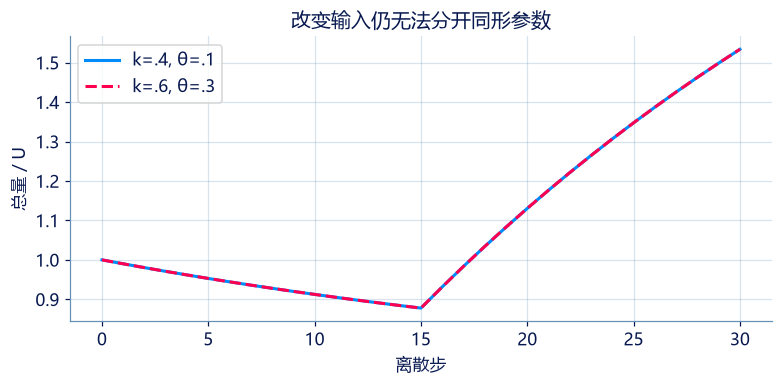

轨迹最大差： 2.220446049250313e-16 ；t=0 独立清除通量： [0.4, 0.6]
预设候选终点预测矩： [1.533833311240807, 0.0]


In [4]:
pairs=[(.4,.1),(.6,.3)];h=.1;inputs=[.2]*15+[.8]*15;paths=[]
for k,theta in pairs:
    x=1.;path=[x]
    for u in inputs:x+=h*confounded_rhs(x,u,k,theta);path.append(x)
    paths.append(path)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(paths[0],label="k=.4, θ=.1",color=BLUE);ax.plot(paths[1],"--",label="k=.6, θ=.3",color=PINK);ax.set(xlabel="离散步",ylabel="总量 / U",title="改变输入仍无法分开同形参数");ax.legend();ax.grid(alpha=.25);plt.show()
print("轨迹最大差：",np.max(np.abs(np.array(paths[0])-paths[1])),"；t=0 独立清除通量：",[k*1. for k,_ in pairs]);print("预设候选终点预测矩：",weighted_prediction([p[-1] for p in paths],[.5,.5]))

## 结果解释

两条总量曲线完全重合，即使输入在中途变化。若只凭这一观测把某一组参数写成“发现的真实机制”，就越过了数据能够区分的范围。额外的通量测量提供不同信息，但也需其自身误差模型。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
for x,u in [(.2,.5),(1.,0.),(2.,.8)]:np.testing.assert_allclose(confounded_rhs(x,u,.4,.1),confounded_rhs(x,u,.6,.3))
np.testing.assert_allclose(paths[0],paths[1]);np.testing.assert_allclose(weighted_prediction([1.,3.],[.25,.75]),[2.5,.75])
print("任意抽样状态的代数等价、两条轨迹与加权矩独立核验。")

任意抽样状态的代数等价、两条轨迹与加权矩独立核验。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：新输入能否破除同形混淆

若右端只含 -(k-θ)x，且只测 x(t)，改变已知输入（input） u(t) 会怎样？

- **A.** 必定分别确定 k 与 θ。
- **B.** 仍只识别 k-θ；需要额外类型的信息，例如独立清除通量。
- **C.** 使 θ 自动变成无量纲（dimensionless）。
- **D.** 使模型（model）无法数值积分。

[作答：新输入能否破除同形混淆](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/practice/?question=p15-confounding-input)

### 第 2 题 · 单项选择题：候选预测方差的范围

给定两组预设参数（parameter）及权重，算出的预测方差（variance）是什么？

- **A.** 所有可能机制的真实后验（posterior）方差。
- **B.** 观测（observation）噪声的唯一估计。
- **C.** 这两组候选及权重下的预测散布，不含遗漏结构。
- **D.** 一定是临床风险。

[作答：候选预测方差的范围](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/practice/?question=p15-candidate-variance)

### 第 3 题 · Python 计算题：同形修正的变化率

计算线性修正模型（model） u-(k-θ)x 的瞬时变化率。

**函数与代码模板**

```python
def solve(
    x: float,
    u: float,
    k: float,
    theta: float,
) -> float:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 当前总量。 | U |
| `u` | `float` | 输入（input）率。 | U/T |
| `k` | `float` | 消除系数。 | 1/T |
| `theta` | `float` | 线性修正系数。 | 1/T |

**返回值**

直接返回 rate（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rate` | `float` | 给定状态（state）变化率。 | U/T |

**计算规则**

变化率 = u-(k-theta)*x。

**约束与边界**

- 输入规模不超过100，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 当前总量。 | 1 | U |
| u | 输入（input）率。 | 0.2 | U/T |
| k | 消除系数。 | 0.4 | 1/T |
| theta | 线性修正系数。 | 0.1 | 1/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 1.0
u = 0.2
k = 0.4
theta = 0.1

result = solve(x, u, k, theta)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rate | 给定状态（state）变化率。 | -0.1 | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = -0.10000000000000003
```

**样例解释**

两组参数（parameter）的 k-θ 都为0.3，因此样例变化率相同。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：同形修正的变化率](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/practice/?question=p15-indistinguishable-rate)

### 第 4 题 · Python 计算题：预设候选的预测矩

先将非负权重归一化，再计算候选值的加权均值和总体加权方差（variance）。

**函数与代码模板**

```python
def solve(
    states: list[float],
    weights: list[float],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 各候选给出的预测状态（state）。 | U |
| `weights` | `list[float]` | 相应非负权重，和为正。 | 1 |

**返回值**

直接返回 moments（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `moments` | `list[float]` | 依次为加权均值及加权方差。 | U、U² |

**计算规则**

先归一化权重；均值=Σw*x，方差=Σw*(x-均值)²。

**约束与边界**

- 状态与权重等长且非空；权重非负且和为正。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| states | 各候选给出的预测状态（state）。 | [1.0, 3.0] | U |
| weights | 相应非负权重，和为正。 | [1.0, 3.0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
states = [1.0, 3.0]
weights = [1.0, 3.0]

result = solve(states, weights)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| moments | 依次为加权均值及加权方差。 | [2.5, 0.75] | U、U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.5, 0.75]
```

**样例解释**

首例归一化权重为1/4和3/4，均值2.5、方差0.75。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：预设候选的预测矩](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/practice/?question=p15-candidate-moments)

**进一步阅读**

[Raissi 等](https://www.sciencedirect.com/science/article/pii/S0021999118307125)与[Chen 等](https://papers.nips.cc/paper_files/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf)提供可微分动力学方法背景；本节参数混淆为教学反例。